# 02 — Model Comparison

How does the 1-D CNN compare to classical machine-learning baselines on the same beats? We compare:

1. **Logistic Regression** (on the raw normalised beat)
2. **Random Forest**
3. **Our 1-D CNN**

This contextualises the deep model: does the extra complexity actually buy us better *per-class* performance on the rare arrhythmias?

> Requires the processed cache (`data/processed/beats.npz`), which is built automatically the first time you run `python -m src.train`, or by calling `build_dataset` below.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

from src.utils import load_config, AAMI_CLASSES
from src.dataset import build_dataset, _split_indices

config = load_config('../config.yaml')
# Point paths at the project root (notebook runs from notebooks/).
config.data['processed_dir'] = '../' + config.data['processed_dir']
config.data['raw_dir'] = '../' + config.data['raw_dir']

cache = build_dataset(config)
data = np.load(cache, allow_pickle=False)
signals, labels, records = data['signals'], data['labels'], data['records']
train_idx, val_idx, test_idx = _split_indices(records, labels, config.data['val_size'], config.data['test_size'], config.seed)
print('train/val/test:', len(train_idx), len(val_idx), len(test_idx))

18:41:03 | INFO     | src.dataset | Using cached dataset at ../data/processed/beats.npz


train/val/test: 68891 16555 15236


## Classical baselines

We feed the flattened, normalised beat straight into scikit-learn models. `class_weight='balanced'` mirrors the CNN's imbalance handling.

In [2]:
X_train, y_train = signals[train_idx], labels[train_idx]
X_test, y_test = signals[test_idx], labels[test_idx]

results = {}

logreg = LogisticRegression(max_iter=200, class_weight='balanced', n_jobs=-1)
logreg.fit(X_train, y_train)
results['Logistic Regression'] = f1_score(y_test, logreg.predict(X_test), average='macro', zero_division=0)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=config.seed)
rf.fit(X_train, y_train)
results['Random Forest'] = f1_score(y_test, rf.predict(X_test), average='macro', zero_division=0)

for name, f1 in results.items():
    print(f'{name:>20}: macro-F1 = {f1:.3f}')

/Users/efeseker/Projects/ECG Arrhythmia Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


/Users/efeseker/Projects/ECG Arrhythmia Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


 Logistic Regression: macro-F1 = 0.288
       Random Forest: macro-F1 = 0.384


## The 1-D CNN

Load the trained checkpoint (train it first with `python -m src.train`) and evaluate it on the same test split for a fair comparison.

In [3]:
import torch
from pathlib import Path
from src.evaluate import load_checkpoint_model, collect_predictions
from src.dataset import ECGBeatDataset
from src.utils import get_device
from torch.utils.data import DataLoader

ckpt = Path('../models/best_model.pt')
if ckpt.exists():
    device = get_device()
    model = load_checkpoint_model(ckpt, config, device)
    test_loader = DataLoader(ECGBeatDataset(X_test, y_test), batch_size=256)
    y_true, y_pred, _ = collect_predictions(model, test_loader, device)
    results['1-D CNN'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # Pass explicit labels so classes absent from this split (e.g. Q on the
    # record-wise split) still line up with target_names instead of erroring.
    labels_all = list(range(len(AAMI_CLASSES)))
    print(classification_report(y_true, y_pred, labels=labels_all,
                                target_names=AAMI_CLASSES, zero_division=0, digits=3))
else:
    print('No checkpoint found - train the model first: python -m src.train')

              precision    recall  f1-score   support

           N      0.869     0.826     0.847     11876
           S      0.181     0.016     0.030      1592
           V      0.496     0.936     0.648      1756
           F      0.002     0.083     0.004        12
           Q      0.000     0.000     0.000         0

    accuracy                          0.754     15236
   macro avg      0.309     0.372     0.306     15236
weighted avg      0.753     0.754     0.738     15236



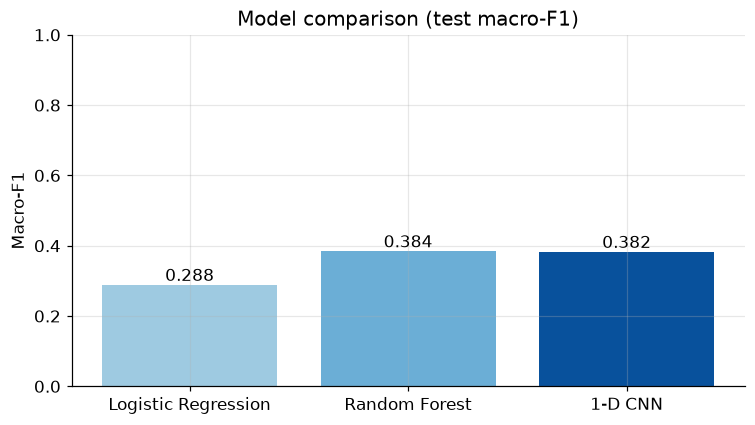

In [4]:
import matplotlib.pyplot as plt
names = list(results.keys()); scores = list(results.values())
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, scores, color=['#9ecae1', '#6baed6', '#08519c'][:len(names)])
ax.set(title='Model comparison (test macro-F1)', ylabel='Macro-F1', ylim=(0, 1))
for b, s in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, s, f'{s:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()